# INKAR Bevölkerungsanalyse & Prognose (nächste Jahre)

Dieses Notebook ist an dein `inkar_load.ipynb` angelehnt, aber fokussiert auf **Bevölkerung** und eine **Prognose für die nächsten Jahre**.

**Was du bekommst**
- Download & Filter der INKAR-Daten (Chunk-weise, speicherschonend)
- Auswahl eines Bevölkerungs‑Indikators (z.B. „Bevölkerung insgesamt“)
- Zeitreihen pro Region (z.B. Kreise) + Forecast (Lineartrend / Holt / SARIMAX)
- Einfaches Backtesting (MAPE) → bestes Modell wird automatisch gewählt
- Plotly‑Grafik mit Dropdown (Region & Modell) + Export der Forecasts als CSV


## 1) Setup

Passe hier die Pfade/Filter an (z.B. Bayern `09`, oder ein anderes Bundesland).


In [9]:
# Optional: wenn dir Pakete fehlen, entkommentieren
# %pip install "pandas>=2.1,<2.3" "pyarrow>=14,<18" "statsmodels>=0.14" "plotly>=5"

from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# --- Region-Filter ---
# INKAR-Kennziffern: Bundesland oft über Prefix erkennbar (z.B. Bayern = "09")
BUNDESLAND_PREFIX = "09"     # <--- ändern, falls du ein anderes Bundesland willst
RAUMBEZUG = "Kreise"         # z.B. "Kreise", "Gemeinden", "Bundesländer", ...

# Forecast-Horizont
FORECAST_YEARS = 10

# Downloaddatei
INKAR_ZIP = DATA_DIR / "inkar.zip"
INKAR_CSV = DATA_DIR / "inkar.csv"

# Output
FILTERED_PARQUET = DATA_DIR / "inkar_filtered.parquet"
FORECAST_CSV = DATA_DIR / "bev_forecast_output.csv"


## Bevölkerungsdichte 

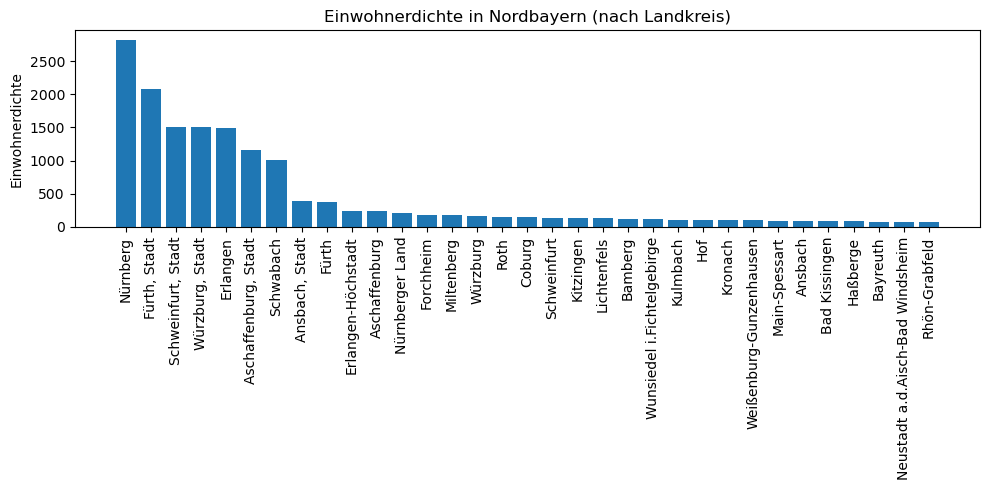

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv("data/merged_nordbayern.csv")

# Sortieren nach Einwohnerdichte
df_sorted = df.sort_values("einwohnerdichte", ascending=False)

# Diagramm
plt.figure(figsize=(10,5))
plt.bar(df_sorted["Raumeinheit"], df_sorted["einwohnerdichte"])
plt.xticks(rotation=90)
plt.ylabel("Einwohnerdichte")
plt.title("Einwohnerdichte in Nordbayern (nach Landkreis)")
plt.tight_layout()
plt.show()

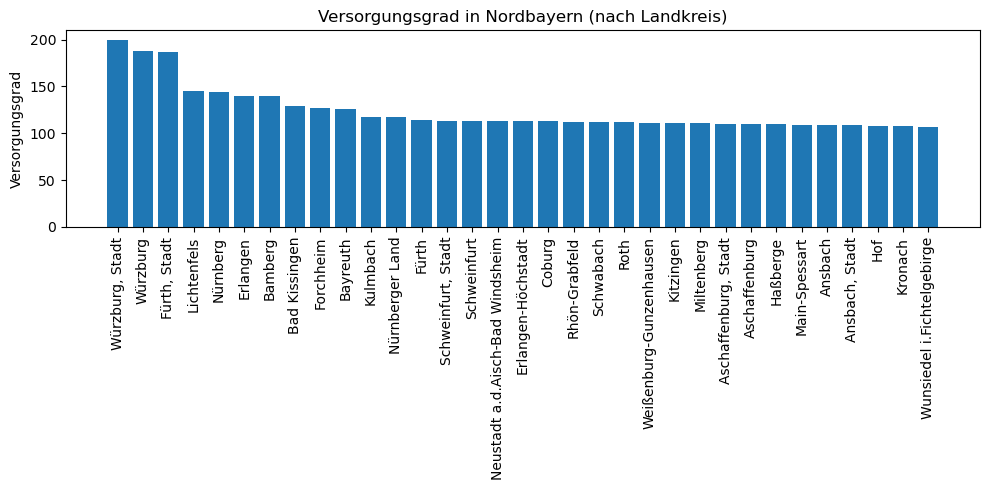

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/merged_nordbayern.csv")

df_sorted = df.sort_values("versorgungsgrad", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(df_sorted["Raumeinheit"], df_sorted["versorgungsgrad"])
plt.xticks(rotation=90)
plt.ylabel("Versorgungsgrad")
plt.title("Versorgungsgrad in Nordbayern (nach Landkreis)")
plt.tight_layout()
plt.show()

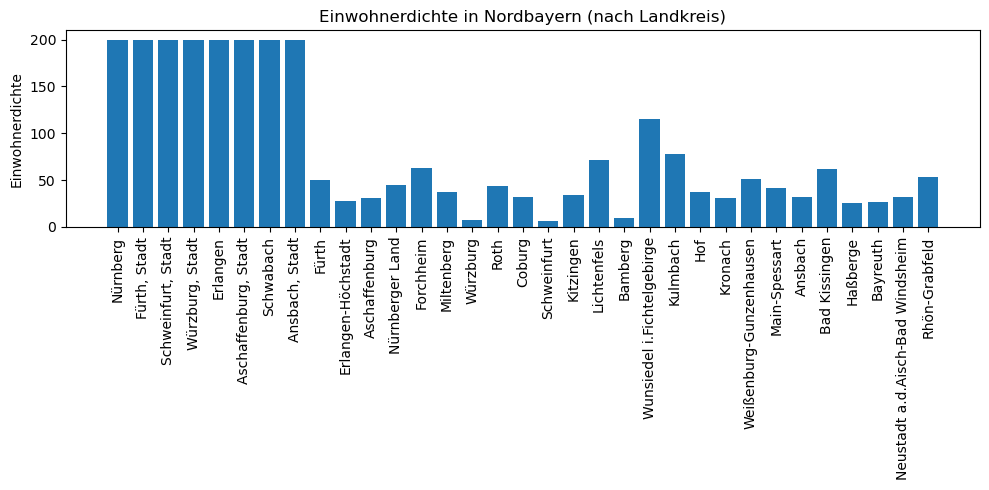

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv("data/merged_nordbayern.csv")

# Sortieren nach Einwohnerdichte
df_sorted = df.sort_values("einwohnerdichte", ascending=False)

# Diagramm
plt.figure(figsize=(10,5))
plt.bar(df_sorted["Raumeinheit"], df_sorted["zentral_score"])
plt.xticks(rotation=90)
plt.ylabel("Einwohnerdichte")
plt.title("Einwohnerdichte in Nordbayern (nach Landkreis)")
plt.tight_layout()
plt.show()

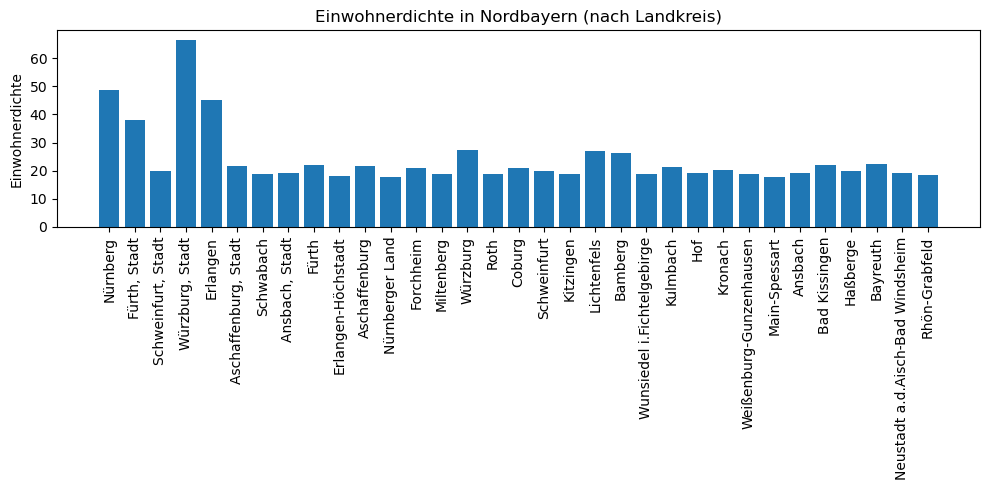

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv("data/merged_nordbayern.csv")

# Sortieren nach Einwohnerdichte
df_sorted = df.sort_values("einwohnerdichte", ascending=False)

# Diagramm
plt.figure(figsize=(10,5))
plt.bar(df_sorted["Raumeinheit"], df_sorted["kass_100k"])
plt.xticks(rotation=90)
plt.ylabel("Einwohnerdichte")
plt.title("Einwohnerdichte in Nordbayern (nach Landkreis)")
plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# 1) Pfad & Datei
# --------------------------------------------------
DATA_DIR = Path(
    "/Users/renatafigueroa/Dokumente/ohm/3.Semester/"
    "Datenvisualisierung /Projekt_Datenvisualisierung/data"
)
FILE = DATA_DIR / "20251215.csv"

# --------------------------------------------------
# 2) CSV laden (Trennzeichen automatisch erkennen)
# --------------------------------------------------
df = pd.read_csv(FILE, sep=None, engine="python", low_memory=False)

# Spaltennamen säubern (falls unsichtbare Leerzeichen drin sind)
df.columns = df.columns.str.strip()

print("Spalten:", list(df.columns))
print("Zeilen (roh):", len(df))

# --------------------------------------------------
# 3) Relevante Spalten prüfen
# --------------------------------------------------
region_col = "Raumeinheit"
value_col = "Bevölkerung gesamt"

if region_col not in df.columns or value_col not in df.columns:
    raise KeyError(f"Spalten nicht gefunden. Erwartet: '{region_col}' und '{value_col}'")

# --------------------------------------------------
# 4) Daten bereinigen
# --------------------------------------------------
# Region: NaN raus, zu String
df = df.dropna(subset=[region_col]).copy()
df[region_col] = df[region_col].astype(str).str.strip()

# Debug: wie sehen die Werte "roh" aus?
print("\nBeispiele (roh) aus 'Bevölkerung gesamt':")
print(df[value_col].head(10))

# Bevölkerung: ALLES außer Ziffern rauswerfen (super robust)
# Beispiel: "1.234.567" -> "1234567", "k.A." -> ""
clean = (
    df[value_col]
    .astype(str)
    .str.replace(r"\D+", "", regex=True)   # entfernt alles außer 0-9
)

df[value_col] = pd.to_numeric(clean, errors="coerce")
df = df.dropna(subset=[value_col]).copy()

print("\nZeilen nach Bereinigung:", len(df))
print("Beispiele (bereinigt):")
print(df[[region_col, value_col]].head(10))

# Wenn immer noch leer: dann hat die Datei wirklich keine Zahlen in der Spalte
if len(df) == 0:
    print("\n❌ Keine gültigen Zahlen in 'Bevölkerung gesamt' gefunden.")
    print("Ein paar unterschiedliche Rohwerte aus der Spalte:")
    print(pd.Series(clean.unique()).head(30).to_list())
    raise SystemExit

# --------------------------------------------------
# 5) Plot (Top 20)
# --------------------------------------------------
df_sorted = df.sort_values(value_col, ascending=False)
top = df_sorted.head(20)

plt.figure(figsize=(12,6))
plt.bar(top[region_col], top[value_col])
plt.xticks(rotation=90)
plt.ylabel("Bevölkerung gesamt")
plt.title("Top 20: Bevölkerung nach Raumeinheit")
plt.tight_layout()
plt.show()

ValueError: The 'low_memory' option is not supported with the 'python' engine